# DIGITAL MODULATIONS CLASSIFIER


## INTRODUCCIÓN


#### En los sistemas de comunicación digital, las señales transmitidas utilizan diferentes tipos de modulación, como BPSK, QPSK, 8PSK, 16-QAM y 64-QAM, para representar información en forma de bits. El problema surge cuando una señal es recibida y no se conoce previamente qué tipo de modulación fue utilizada. Esta situación es común en escenarios de monitoreo del espectro radioeléctrico, análisis de señales inalámbricas, radio definida por software, comunicaciones cognitivas e identificación de interferencias. Por ello, clasificar automáticamente el tipo de modulación se convierte en una tarea importante para interpretar correctamente una señal y facilitar procesos posteriores como su análisis, demodulación o gestión.

#### El problema a resolver en este proyecto consiste en desarrollar un modelo de machine learning capaz de identificar automáticamente la modulación digital de una señal a partir de sus componentes IQ, es decir, la información en fase y cuadratura que describe el comportamiento de la señal. Esta tarea no es sencilla, porque las modulaciones pueden presentar patrones similares entre sí, especialmente cuando existe ruido en el canal o cuando se trabaja con modulaciones más complejas como 16-QAM y 64-QAM. Además, el desempeño del clasificador puede variar según el nivel de SNR, lo que hace necesario evaluar si el modelo logra aprender diferencias reales entre las clases.

#### La importancia de este problema radica en que la clasificación automática de modulaciones permite reducir la dependencia de métodos manuales o basados exclusivamente en reglas diseñadas por expertos. En lugar de extraer características de forma tradicional, una red neuronal puede aprender patrones directamente desde los datos. En este proyecto se utilizará una red neuronal tipo MLP sobre el dataset RML2016.10A, seleccionando las modulaciones BPSK, QPSK, 8PSK, 16-QAM y 64-QAM. Con esto, se busca aplicar una metodología completa de aprendizaje automático para construir, optimizar y evaluar un modelo capaz de clasificar señales digitales, analizando además cómo el ruido afecta su rendimiento.

## EDA

### Cargar el archivo

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "../../data/RML2016.10a_dict.pkl"

with open(path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

### Claves del diccionario

In [3]:
keys = list(data.keys())

print("Número de combinaciones modulación-SNR:", len(keys))
print("Primeras claves:")
print(keys[:20])

Número de combinaciones modulación-SNR: 220
Primeras claves:
[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8), ('AM-SSB', 12), ('8PSK', 8), ('8PSK', 12), ('QAM64', -6), ('QAM16', 2), ('QAM16', -20), ('PAM4', -6), ('WBFM', -18), ('AM-DSB', 16), ('CPFSK', 10), ('WBFM', 6), ('BPSK', 4), ('BPSK', -2), ('QPSK', -20), ('CPFSK', -8)]


In [4]:
# Se separa modulaciones y SNR disponibles
mods = sorted(list(set([k[0] for k in keys])))
snrs = sorted(list(set([k[1] for k in keys])))

print("Modulaciones disponibles:", mods)
print("SNR disponibles:", snrs)

Modulaciones disponibles: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR disponibles: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [5]:
selected_mods = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

### Forma de los datos IQ

In [6]:
example_key = keys[0]
example_data = data[example_key]

print("Clave ejemplo:", example_key)
print("Forma del arreglo:", example_data.shape)

Clave ejemplo: ('QPSK', 2)
Forma del arreglo: (1000, 2, 128)


###### El dataset está organizado como un diccionario donde cada clave corresponde a una combinación entre modulación y SNR. Cada clave tiene la forma (modulación, SNR), por ejemplo ('QPSK', 18). El valor asociado a cada clave es un arreglo con forma (1000, 2, 128), donde 1000 representa el número de señales, 2 corresponde a los canales I y Q, y 128 representa las muestras temporales de cada señal.

### DataFrame resumen del dataset

In [7]:
summary = []

for (mod, snr), samples in data.items():
    summary.append({
        "modulation": mod,
        "snr": snr,
        "num_samples": samples.shape[0],
        "channels": samples.shape[1],
        "signal_length": samples.shape[2]
    })

df_summary = pd.DataFrame(summary)
df_summary.head()

,modulation,snr,num_samples,channels,signal_length
0,QPSK,2,1000,2,128
1,PAM4,8,1000,2,128
2,AM-DSB,-4,1000,2,128
3,GFSK,6,1000,2,128
4,QAM64,8,1000,2,128


In [8]:
# modulaciones a usar
selected_mods = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

df_selected = df_summary[df_summary["modulation"].isin(selected_mods)]

df_selected.head()


,modulation,snr,num_samples,channels,signal_length
0,QPSK,2,1000,2,128
4,QAM64,8,1000,2,128
6,8PSK,8,1000,2,128
7,8PSK,12,1000,2,128
8,QAM64,-6,1000,2,128


### Balance por clase

In [9]:
class_counts = df_selected.groupby("modulation")["num_samples"].sum()
print(class_counts)

modulation
8PSK     20000
BPSK     20000
QAM16    20000
QAM64    20000
QPSK     20000
Name: num_samples, dtype: int64


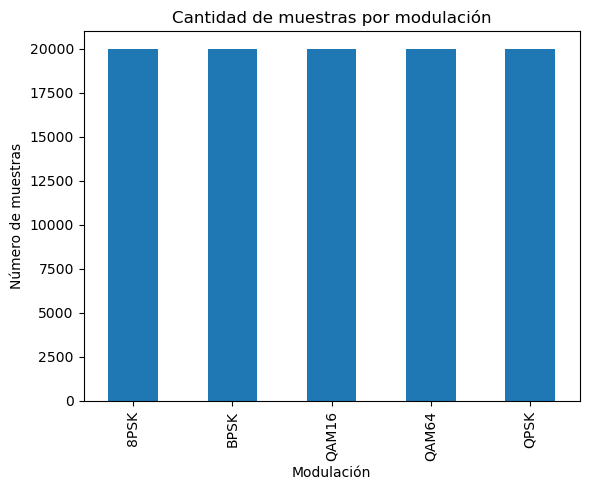

In [10]:
class_counts.plot(kind="bar")
plt.title("Cantidad de muestras por modulación")
plt.xlabel("Modulación")
plt.ylabel("Número de muestras")
plt.show()

### Distribución por SNR

In [11]:
snr_counts = df_selected.groupby("snr")["num_samples"].sum()
print(snr_counts)

snr
-20    5000
-18    5000
-16    5000
-14    5000
-12    5000
-10    5000
-8     5000
-6     5000
-4     5000
-2     5000
 0     5000
 2     5000
 4     5000
 6     5000
 8     5000
 10    5000
 12    5000
 14    5000
 16    5000
 18    5000
Name: num_samples, dtype: int64


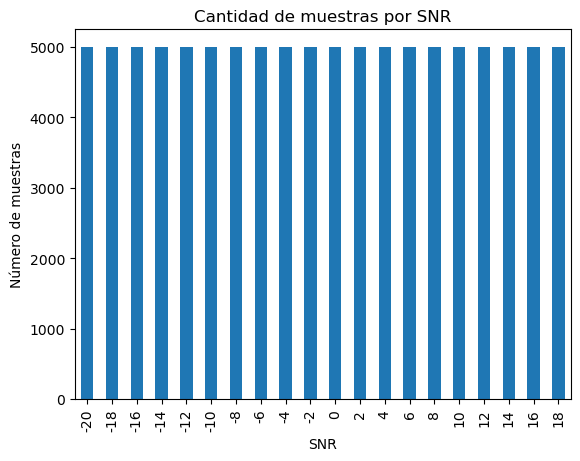

In [12]:
snr_counts.plot(kind="bar")
plt.title("Cantidad de muestras por SNR")
plt.xlabel("SNR")
plt.ylabel("Número de muestras")
plt.show()

### Distribución cruzada modulación-SNR

In [13]:
pivot = df_selected.pivot_table(
    values="num_samples",
    index="modulation",
    columns="snr",
    aggfunc="sum"
)

pivot

snr,-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18
modulation,,,,,,,,,,,,,,,,,,,,
8PSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
BPSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QAM16,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QAM64,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QPSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000


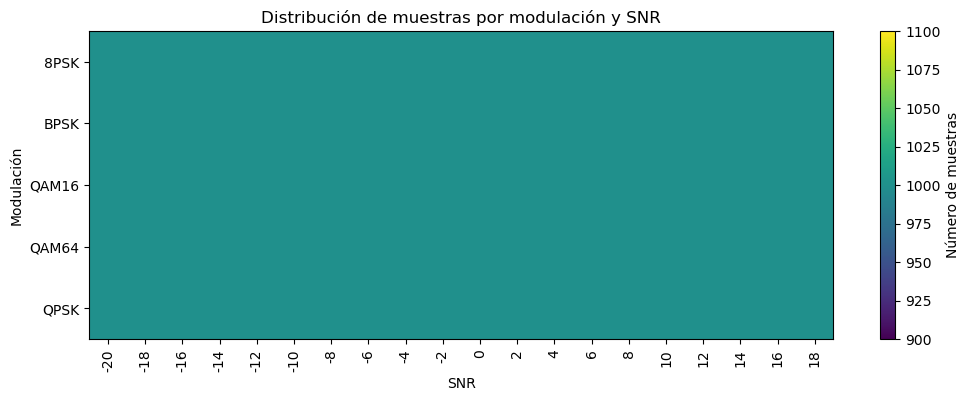

In [14]:
plt.figure(figsize=(12, 4))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Número de muestras")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Distribución de muestras por modulación y SNR")
plt.xlabel("SNR")
plt.ylabel("Modulación")
plt.show()

### Construir dataset final X, y, SNR

In [15]:
X = []
y = []
snr_values = []

for (mod, snr), samples in data.items():
    if mod in selected_mods:
        X.append(samples)
        y.extend([mod] * samples.shape[0])
        snr_values.extend([snr] * samples.shape[0])

X = np.vstack(X)
y = np.array(y)
snr_values = np.array(snr_values)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr shape:", snr_values.shape)

X shape: (100000, 2, 128)
y shape: (100000,)
snr shape: (100000,)


In [16]:
X_flat = X.reshape(X.shape[0], -1)

print("X para MLP:", X_flat.shape)

X para MLP: (100000, 256)


### Faltantes, infinitos o anómalos

In [17]:
print("NaN:", np.isnan(X).sum())
print("Inf:", np.isinf(X).sum())

print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Media:", X.mean())
print("Desviación estándar:", X.std())


NaN: 0
Inf: 0
Valor mínimo: -0.15494554
Valor máximo: 0.16422912
Media: -4.7892547e-05
Desviación estándar: 0.0060583474


### Señales IQ en el tiempo

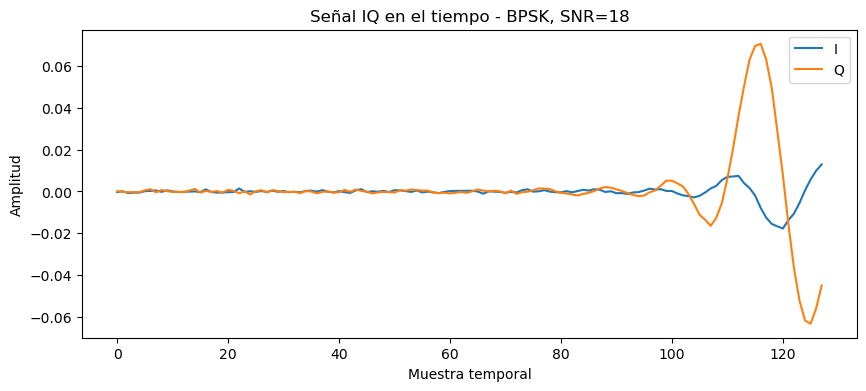

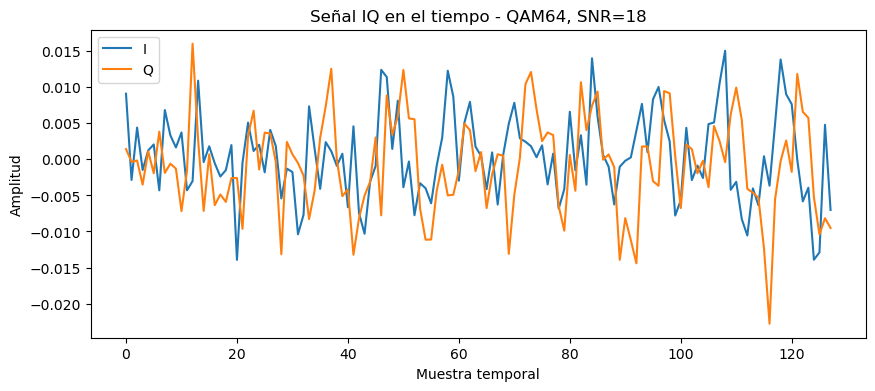

In [18]:
def plot_iq_signal(X, y, snr_values, modulation, snr, index=0):
    idx = np.where((y == modulation) & (snr_values == snr))[0]
    sample = X[idx[index]]
    
    I = sample[0]
    Q = sample[1]
    
    plt.figure(figsize=(10, 4))
    plt.plot(I, label="I")
    plt.plot(Q, label="Q")
    plt.title(f"Señal IQ en el tiempo - {modulation}, SNR={snr}")
    plt.xlabel("Muestra temporal")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.show()

plot_iq_signal(X, y, snr_values, "BPSK", 18)
plot_iq_signal(X, y, snr_values, "QAM64", 18)

### Constelaciones

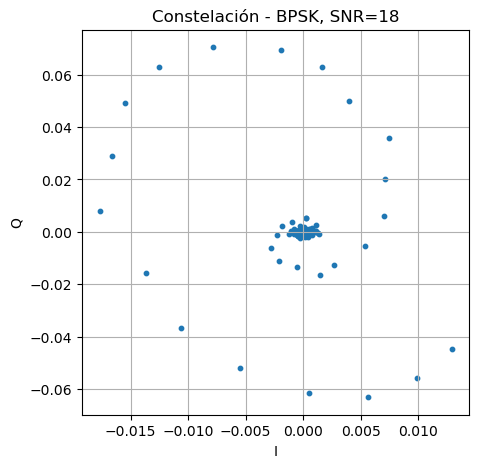

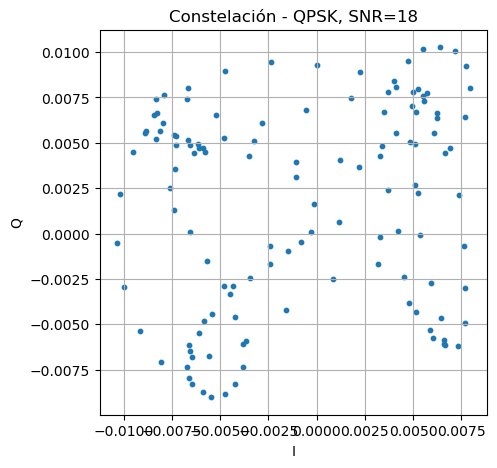

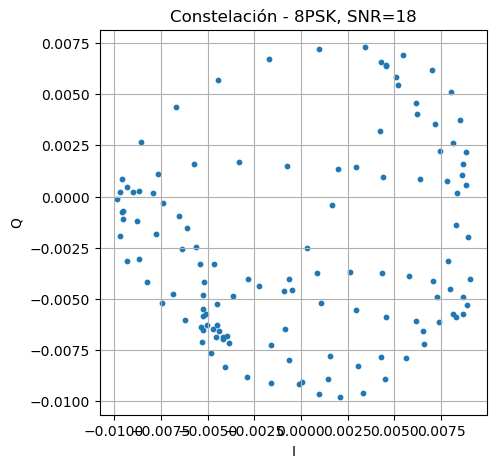

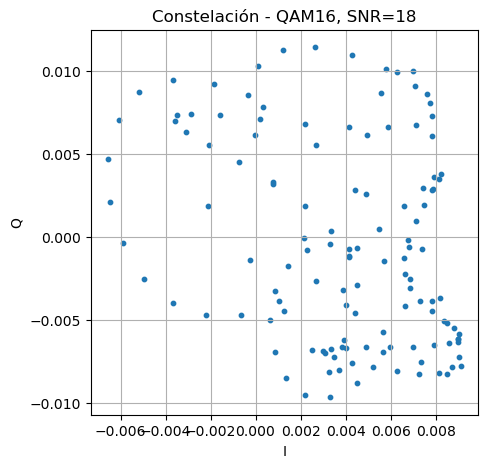

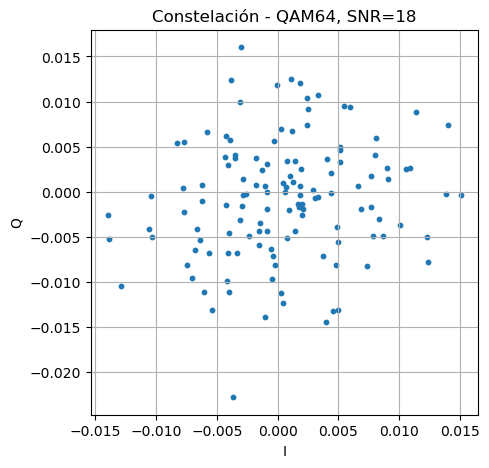

In [19]:
def plot_constellation(X, y, snr_values, modulation, snr, index=0):
    idx = np.where((y == modulation) & (snr_values == snr))[0]
    sample = X[idx[index]]
    
    I = sample[0]
    Q = sample[1]
    
    plt.figure(figsize=(5, 5))
    plt.scatter(I, Q, s=10)
    plt.title(f"Constelación - {modulation}, SNR={snr}")
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.grid(True)
    plt.show()

for mod in selected_mods:
    plot_constellation(X, y, snr_values, mod, 18)


In [26]:
def compare_constellation_snr(X, y, snr_values, modulation, snr_high=18, snr_low=-10, index=0):
    # Índices para SNR alto
    idx_high = np.where((y == modulation) & (snr_values == snr_high))[0]
    sample_high = X[idx_high[index]]
    
    I_high = sample_high[0]
    Q_high = sample_high[1]
    
    # Índices para SNR bajo
    idx_low = np.where((y == modulation) & (snr_values == snr_low))[0]
    sample_low = X[idx_low[index]]
    
    I_low = sample_low[0]
    Q_low = sample_low[1]
    
    # Gráficas comparativas
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].scatter(I_high, Q_high, s=10)
    axes[0].set_title(f"{modulation}, SNR={snr_high}")
    axes[0].set_xlabel("I")
    axes[0].set_ylabel("Q")
    axes[0].grid(True)
    axes[0].axis("equal")
    
    axes[1].scatter(I_low, Q_low, s=10)
    axes[1].set_title(f"{modulation}, SNR={snr_low}")
    axes[1].set_xlabel("I")
    axes[1].set_ylabel("Q")
    axes[1].grid(True)
    axes[1].axis("equal")
    
    plt.suptitle(f"Comparación de constelaciones para {modulation}")
    plt.show()

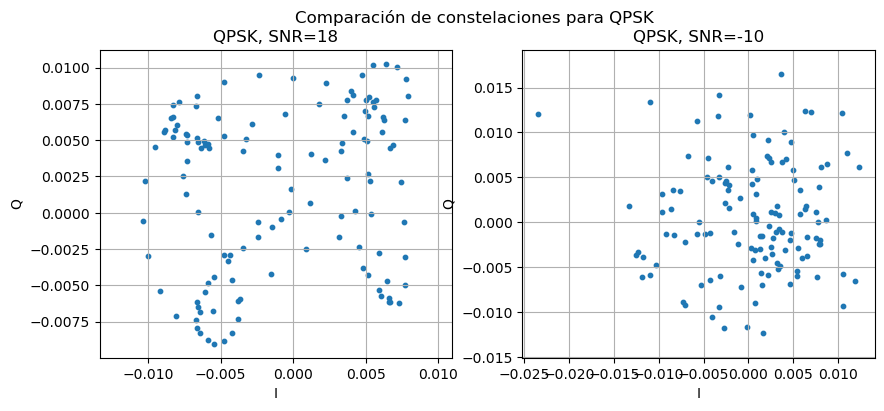

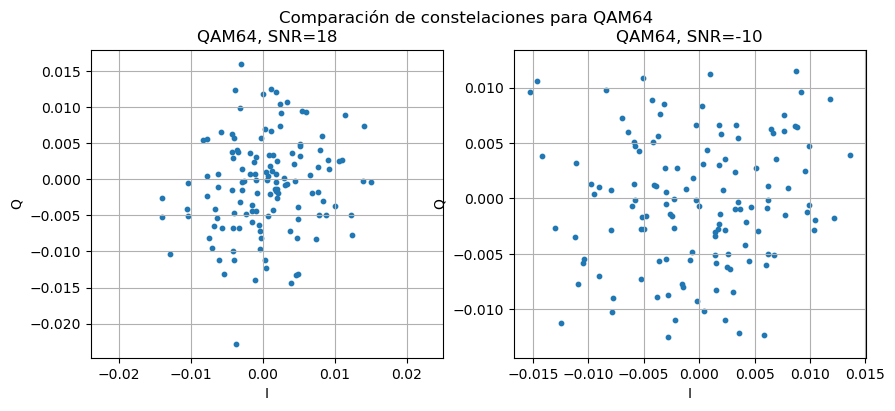

In [27]:
compare_constellation_snr(X, y, snr_values, "QPSK", 18, -10)
compare_constellation_snr(X, y, snr_values, "QAM64", 18, -10)

### Analizar amplitud y fase

In [21]:
I = X[:, 0, :]
Q = X[:, 1, :]

amplitude = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)

print("Amplitude shape:", amplitude.shape)
print("Phase shape:", phase.shape)

Amplitude shape: (100000, 128)
Phase shape: (100000, 128)


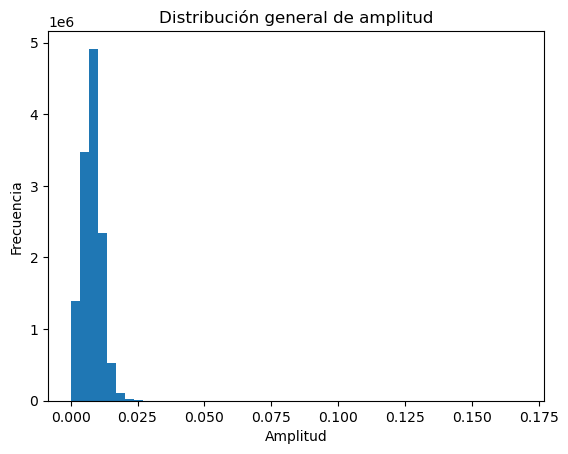

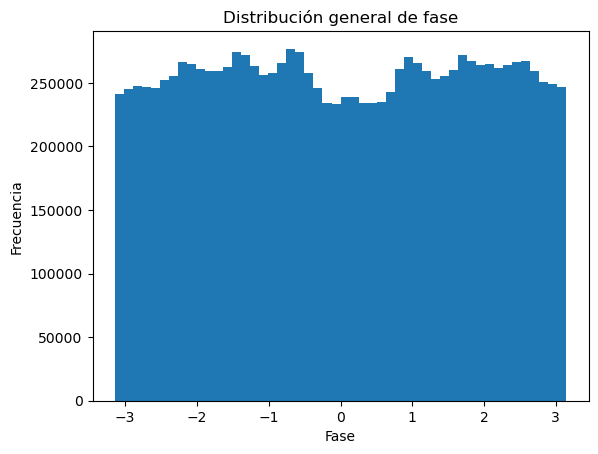

In [22]:
plt.hist(amplitude.flatten(), bins=50)
plt.title("Distribución general de amplitud")
plt.xlabel("Amplitud")
plt.ylabel("Frecuencia")
plt.show()

plt.hist(phase.flatten(), bins=50)
plt.title("Distribución general de fase")
plt.xlabel("Fase")
plt.ylabel("Frecuencia")
plt.show()

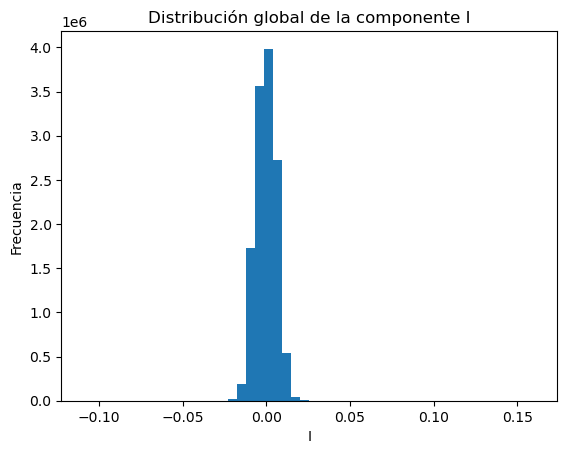

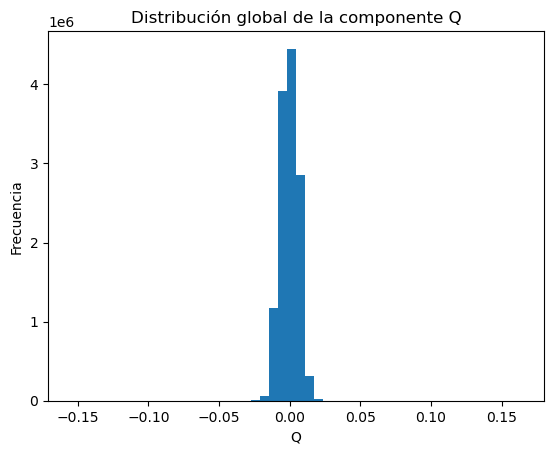

In [23]:
# Distribución global de I y Q
I = X[:, 0, :]
Q = X[:, 1, :]

plt.hist(I.flatten(), bins=50)
plt.title("Distribución global de la componente I")
plt.xlabel("I")
plt.ylabel("Frecuencia")
plt.show()

plt.hist(Q.flatten(), bins=50)
plt.title("Distribución global de la componente Q")
plt.xlabel("Q")
plt.ylabel("Frecuencia")
plt.show()

### Potencia promedio por modulación

In [24]:
power = np.mean(I**2 + Q**2, axis=1)

df_features = pd.DataFrame({
    "modulation": y,
    "snr": snr_values,
    "power": power
})

df_features.groupby("modulation")["power"].describe()

,count,mean,std,min,25%,50%,75%,max
modulation,,,,,,,,
8PSK,20000.0,0.000072,0.000009,0.000062,0.000066,0.000073,0.000078,0.000491
BPSK,20000.0,0.000074,0.000007,0.000063,0.000070,0.000074,0.000078,0.000533
QAM16,20000.0,0.000074,0.000009,0.000064,0.000070,0.000073,0.000077,0.000647
QAM64,20000.0,0.000074,0.000011,0.000064,0.000071,0.000073,0.000076,0.000519
QPSK,20000.0,0.000072,0.000009,0.000062,0.000066,0.000073,0.000078,0.000477


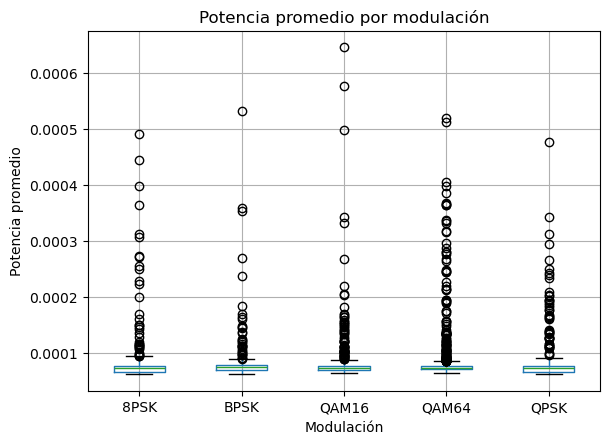

In [25]:
df_features.boxplot(column="power", by="modulation")
plt.title("Potencia promedio por modulación")
plt.suptitle("")
plt.xlabel("Modulación")
plt.ylabel("Potencia promedio")
plt.show()

El dataset seleccionado contiene 100 000 señales IQ correspondientes a cinco modulaciones digitales: BPSK, QPSK, 8PSK, QAM16 y QAM64. Cada señal tiene dos componentes, I y Q, con 128 muestras temporales, lo que produce 256 características al preparar los datos para una red neuronal MLP. El análisis mostró que el conjunto está balanceado por clase y por nivel de SNR, con 20 000 muestras por modulación y 5000 muestras por cada nivel de SNR.

Además, no se encontraron valores faltantes ni infinitos. Los valores IQ se encuentran normalizados alrededor de cero, con un rango aproximado entre -0.155 y 0.164. Las gráficas de señales IQ, amplitud, fase y potencia muestran que los datos corresponden a señales crudas y normalizadas, no a símbolos demodulados ideales. Por esta razón, las constelaciones no aparecen como puntos perfectos, sino como nubes, trayectorias o agrupaciones afectadas por transiciones, ruido y variaciones propias de la señal.

Finalmente, la potencia promedio calculada corresponde a una potencia normalizada en unidades arbitrarias, no a watts ni dBm. Las potencias promedio son similares entre modulaciones, lo que sugiere que la clasificación no puede basarse únicamente en la energía de la señal, sino que requiere aprender patrones más complejos de las componentes IQ.